## imports

In [350]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# load dataset

In [351]:

# Load your dataset
df = pd.read_csv('../Loan_Data.csv')

print(df.head())

print(df.dtypes)

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

# Feature Selection and feature enginnering

In [352]:
# Combining incomes
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']

# Remove rows where the target 'LoanAmount' is NaN
df = df.dropna(subset=['LoanAmount','ApplicantIncome','CoapplicantIncome'])



X = df.drop(['Loan_ID', 'LoanAmount'], axis=1)
y = df['LoanAmount']

# Data pre processing and cleaning

In [353]:
# Separate columns by type
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

num_cols = [col for col in num_cols if col not in ['LoanAmount', 'Loan_ID']]
cat_cols = [col for col in cat_cols if col not in ['LoanAmount', 'Loan_ID']]

# Fill numeric gaps with Median
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical gaps with Mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [354]:
# Grouping columns by type (becuse we need to apply different transformations for numerical and categorical features)
numeric_features = ['ApplicantIncome', 'CoapplicantIncome', 'Loan_Amount_Term', 'Credit_History']
categorical_features = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

Model training

In [355]:
# Numeric Pipeline: Impute missing with median and scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Pipeline: Impute missing with mode and One-Hot Encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Combine transformers into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])

# 4. Model Selection & Training (Step 6)
# Create the full pipeline with Linear Regression
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# 5. Split the Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the model
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'Loan_Amount_Term',
                                                   'Credit_History',
                                                   'Total_Income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Gender', 'Married',
                                                   'Dependents', 'Education',
                                                   'Self_Employed',
                                                   'Property_Area',
                                                   'Loan_Status'])])),
                ('regressor', LinearRegression())])

 Model Evaluation 

In [356]:
y_pred = model_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- Model Performance ---")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

# 3. Calculate "Accuracy" Percentage (Optional)
# In regression, we can look at the Mean Absolute Percentage Error
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Model Accuracy: {100 - mape:.2f}%")

--- Model Performance ---
Mean Absolute Error: 36.99
Root Mean Squared Error: 57.79
Mean Absolute Percentage Error (MAPE): 35.55%
Model Accuracy: 64.45%


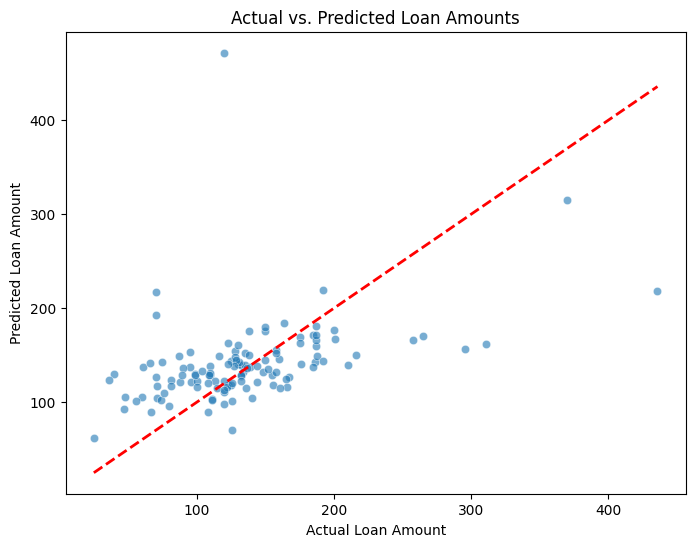